In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statistics as sts

In [ ]:
from google.colab import drive

drive.mount("/content/drive")
file_path = "/content/drive/My Drive/Colab Notebooks"

Mounted at /content/drive


Age[Idade]: idade do paciente [anos(years)]

Gênero[Sex]: gênero do paciente [M: Masculino (Male), F: Feminino (Female)]

Tipo de Dor no peito[ChestPainType]: Tipo de dor no peito do paciente [Angina Típica(TA: Typical Angina), Angina Atípica(ATA: Atypical Angina), Dor Não Anginosa (NAP: Non-Anginal Pain), Assintomático(ASY: Asymptomatic)]

[RestingBP]: Pressão Arterial em Repouso (resting blood pressure [mm Hg])

Cholesterol: Colesterol (serum cholesterol [mm/dl])

FastingBS: glicemia de jejum (fasting blood sugar [1: if FastingBS > 120 mg/dl, 0: otherwise])

RestingECG: resting electrocardiogram results [Normal: Normal, ST: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV), LVH: showing probable or definite left ventricular hypertrophy by Estes' criteria]

MaxHR: Frequência Cardíaca Máxima (maximum heart rate achieved [Numeric value between 60 and 202])

ExerciseAngina: Angina Induzida por Exercício (exercise-induced angina [Y: Yes, N: No])

Oldpeak: Depressão de ST[Medida importante para identificar falta de fluxo sanguíneo para o coração] (oldpeak = ST [Numeric value measured in depression])

ST_Slope:  Inclinação do Segmento ST (the slope of the peak exercise ST segment [Up: upsloping, Flat: flat, Down: downsloping])

HeartDisease: doença do coração[1: doente do coração, 2: normal] (output class [1: heart disease, 0: Normal])

In [ ]:
DataFrame = pd.read_csv(f"{file_path}/heart.csv")

In [ ]:
contagem = DataFrame['HeartDisease'].value_counts()
contagem

,count
HeartDisease,
1,508
0,410


In [ ]:
idade_limite = 54
total_pessoas_mais_54 = len(DataFrame[DataFrame['Age'] > idade_limite])
total_com_doenca_mais_54 = len(DataFrame[(DataFrame['Age'] > idade_limite) & (DataFrame['HeartDisease'] == 1)])

percentual_doenca = (total_com_doenca_mais_54 / total_pessoas_mais_54) * 100

In [ ]:
paleta1 = sns.color_palette(["#1637E0", "#58E8F9"])


##**Idade X Doença no Coração**

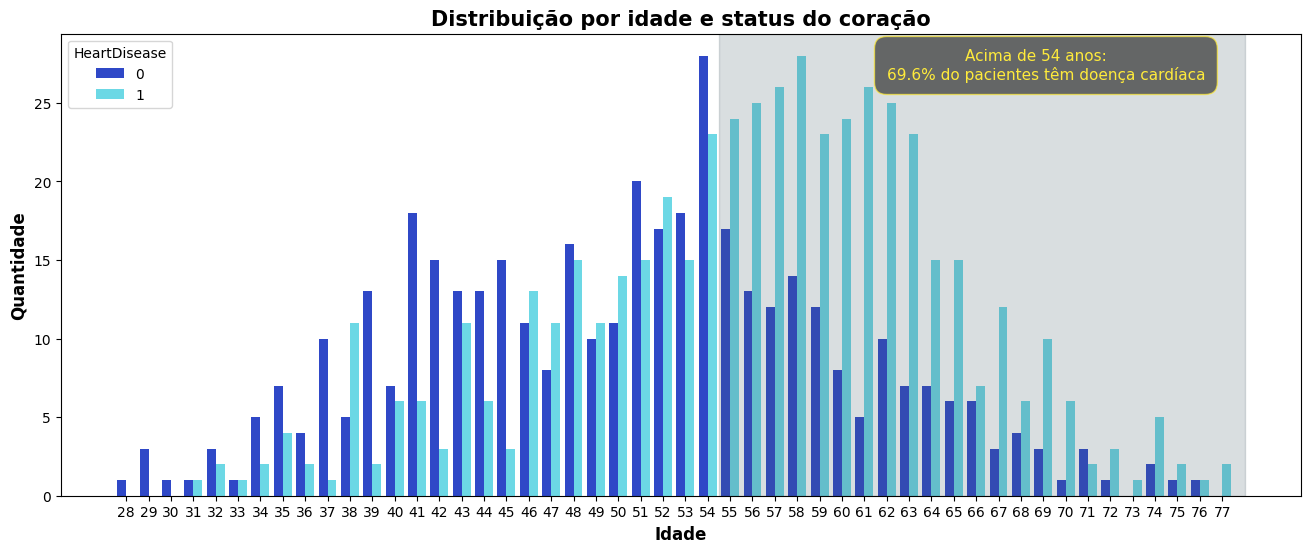

In [ ]:
plt.figure(figsize=(16, 6), dpi = 100)
ax = sns.countplot(x = 'Age', hue = 'HeartDisease', data = DataFrame, palette= paleta1)
plt.axvspan(26.5, 50, color="#455A64", alpha=0.2)
plt.text(34, 26.5,  f"                Acima de 54 anos:\n{percentual_doenca:.1f}% do pacientes têm doença cardíaca", fontsize=11,color="#FFEB3B", bbox=dict(facecolor='#333333', alpha=0.7, edgecolor="#FFEB3B", boxstyle="round,pad=0.8"))
plt.title('Distribuição por idade e status do coração',fontsize = 15, fontweight='bold')
plt.xlabel('Idade',fontsize = 12, fontweight='bold')
plt.ylabel('Quantidade',fontsize = 12, fontweight='bold')
plt.show()

##**Angina Induzida por Exercício X Doença no coração**

In [ ]:
paleta = sns.color_palette(["#1976D2","#D32F2F"])

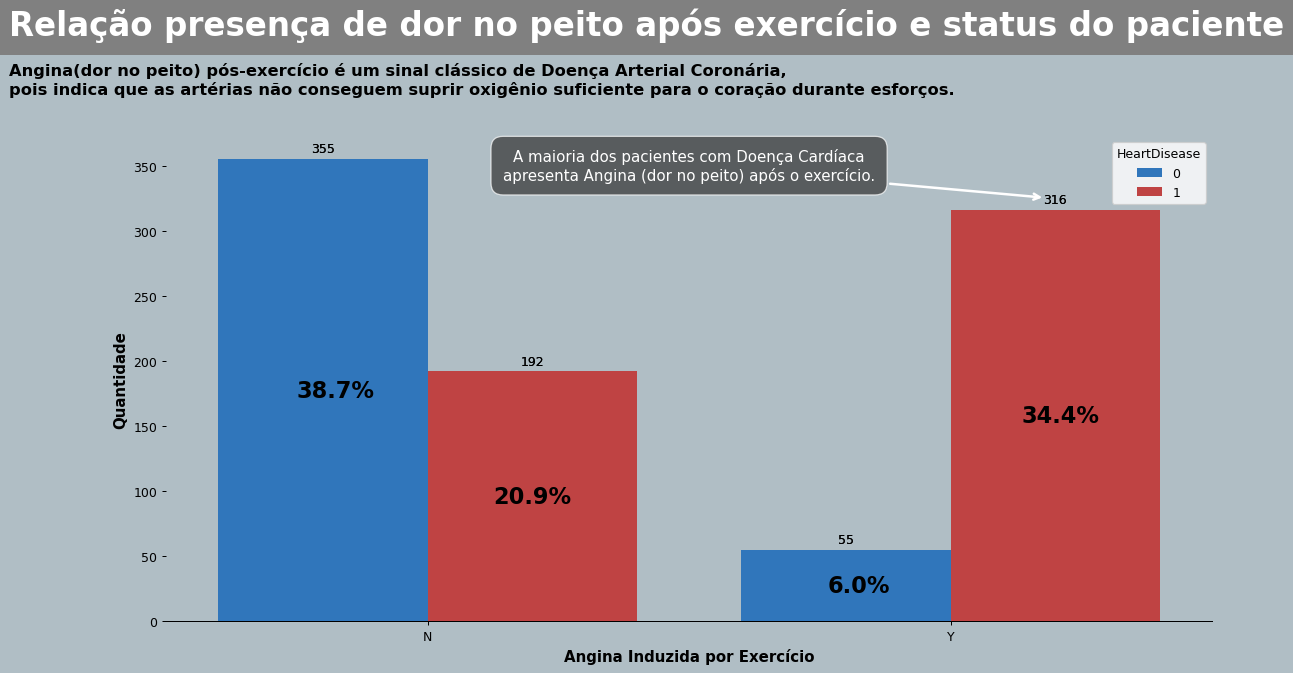

In [ ]:
fig, ax = plt.subplots(figsize=(15, 7),dpi=90)

# Criando o gráfico de contagem
ax = sns.countplot(x='ExerciseAngina', hue='HeartDisease', data=DataFrame, palette=paleta)

ax.tick_params(bottom='off', left='off', labelleft='off', labelbottom='on')
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Total de observações para calcular as porcentagens
total = len(DataFrame)

heights = []

percentages = []
for container in ax.containers:
    for bar in container:
        height = bar.get_height()  # Pega a altura da barra (contagem)
        percentage = 100 * height / total  # Calcula a porcentagem da barra
        percentages.append(percentage)  # Adiciona a porcentagem à lista

# Adicionando rótulos sobre as barras com porcentagens
for container in ax.containers:
    for bar in container:
        height = bar.get_height()  # Captura a altura da barra
        heights.append(height)  # Adiciona a altura à lista
        ax.bar_label(container, fmt='%d', label_type='edge', padding=3)




# Personalizando o fundo e os textos
background_color = '#B0BEC5'
fig.set_facecolor(background_color)
ax.set_facecolor(background_color)



# Título do gráfico

ax.set_xlabel('Angina Induzida por Exercício', fontsize = 12, fontweight='bold')
ax.set_ylabel('Quantidade', fontsize = 12, fontweight='bold')


# Adicionando anotação ao gráfico
ax.annotate("A maioria dos pacientes com Doença Cardíaca\napresenta Angina (dor no peito) após o exercício.",
            xy=(1.18, max(DataFrame['ExerciseAngina'].value_counts()) * 0.595),  # Ponta da seta (destino)
            xytext=(0.5, max(DataFrame['ExerciseAngina'].value_counts()) * 0.64),  # Posição do texto (origem)
            fontsize=12, ha='center', va='center', color="white",
            bbox=dict(facecolor='#333333', alpha=0.7, edgecolor='white',boxstyle="round,pad=0.8"),  # Caixa ao redor do texto
            arrowprops=dict(arrowstyle='->', color='white', lw=2))  # Seta normal

ax.text(-0.175, heights[0]/2, f'{percentages[0]:.1f}%',fontweight='bold', fontsize=18,ha='center', va='center')

ax.text(0.825, heights[1]/2, f'{percentages[1]:.1f}%',fontweight='bold', fontsize=18,ha='center', va='center')

ax.text(0.2, heights[2]/2, f'{percentages[2]:.1f}%',fontweight='bold', fontsize=18,ha='center', va='center')

ax.text(1.21, heights[3]/2, f'{percentages[3]:.1f}%',fontweight='bold', fontsize=18,ha='center', va='center')

plt.text(-0.8,405, 'Angina(dor no peito) pós-exercício é um sinal clássico de Doença Arterial Coronária,\npois indica que as artérias não conseguem suprir oxigênio suficiente para o coração durante esforços.', fontsize=13,
         color="black", fontweight='bold')



plt.text(-0.8, 450,
         'Relação presença de dor no peito após exercício e status do paciente',
         fontsize=26,
         color='white',
         fontweight='bold',
         bbox={'facecolor': "gray",  # background color
               'pad': 10,  # add more padding
               'edgecolor': 'none'})  # no border

plt.show()


In [ ]:
import scipy.stats as stats



# Criar uma tabela de contingência (Tipo de dor no peito vs. Presença de doença cardíaca)
contingency_table = pd.crosstab(DataFrame["ExerciseAngina"], DataFrame["HeartDisease"])

# Exibir a tabela
print("\nTabela de Contingência:")
print(contingency_table)

# Aplicar o teste qui-quadrado
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

# Exibir os resultados
print("\nResultados do Teste Qui-Quadrado:")
print(f"Qui-quadrado: {chi2:.4f}")
print(f"p-valor: {p:.4f}")
print(f"Graus de liberdade: {dof}")
print("\nValores esperados da tabela:")
print(pd.DataFrame(expected, index=contingency_table.index, columns=contingency_table.columns))

# Interpretar o p-valor
alpha = 0.05  # Nível de significância
if p < alpha:
    print("\nConclusão: Existe uma associação estatisticamente significativa entre a presença de dor no peito após exercício e a presença de doença cardíaca.")
else:
    print("\nConclusão: Não há evidências estatísticas de associação entre  a presença de dor no peito após exercício e a presença de doença cardíaca.")



Tabela de Contingência:
HeartDisease      0    1
ExerciseAngina          
N               355  192
Y                55  316

Resultados do Teste Qui-Quadrado:
Qui-quadrado: 222.2594
p-valor: 0.0000
Graus de liberdade: 1

Valores esperados da tabela:
HeartDisease             0           1
ExerciseAngina                        
N               244.302832  302.697168
Y               165.697168  205.302832

Conclusão: Existe uma associação estatisticamente significativa entre a presença de dor no peito após exercício e a presença de doença cardíaca.


In [ ]:
paleta3 = sns.color_palette(["#9C27B0", "#FF9800"])

In [ ]:
from matplotlib import transforms, pyplot as plt
import matplotlib.patches as patches

In [ ]:
percentages = []
for container in ax.containers:
    for bar in container:
        height = bar.get_height()  # Pega a altura da barra (contagem)
        percentage = 100 * height / total  # Calcula a porcentagem da barra
        percentages.append(percentage)  # Adiciona a porcentagem à lista



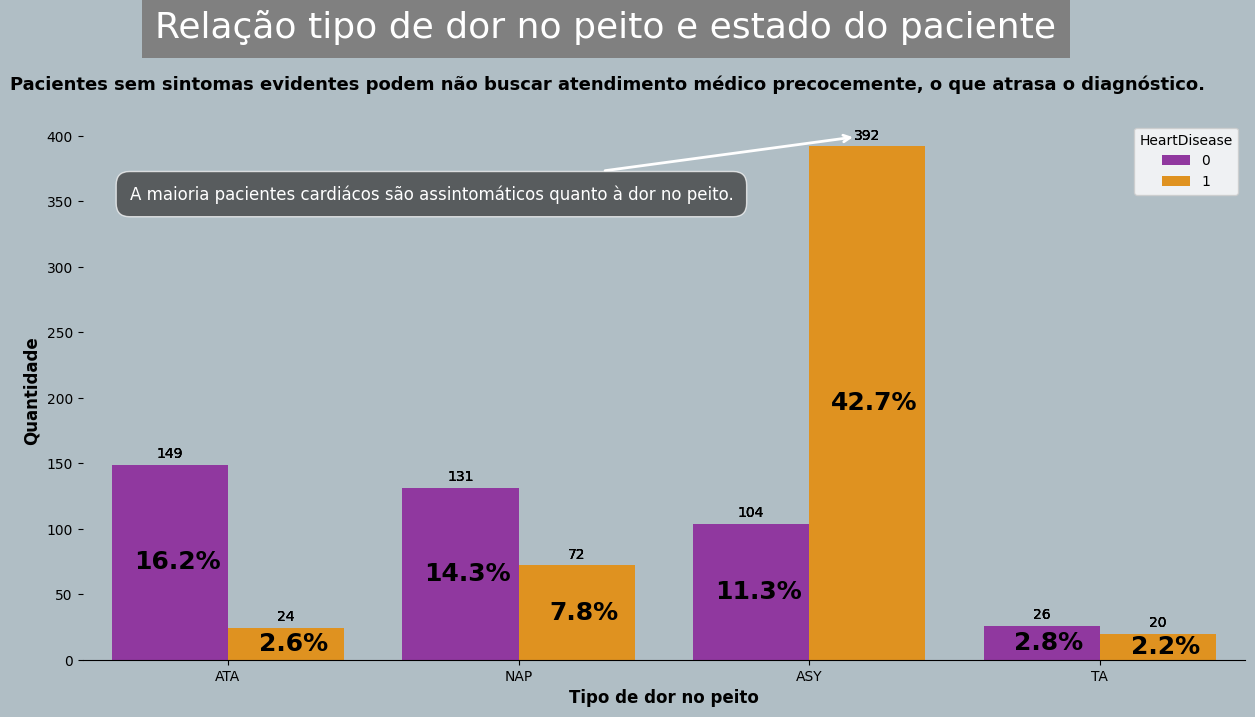

In [ ]:
fig, ax = plt.subplots(figsize=(15, 7), dpi=100)


# Criando o gráfico de contagem
ax = sns.countplot(x='ChestPainType', hue='HeartDisease', data=DataFrame, palette=paleta3)

ax.tick_params(bottom='off', left='off', labelleft='off', labelbottom='on')
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Total de observações para calcular as porcentagens
total = len(DataFrame)

heights = []

# Adicionando rótulos sobre as barras com porcentagens
for container in ax.containers:
    for bar in container:
        height = bar.get_height()  # Captura a altura da barra
        heights.append(height)  # Adiciona a altura à lista
        ax.bar_label(container, fmt='%d', label_type='edge', padding=3)

# Personalizando o fundo e os textos
background_color = '#B0BEC5'
fig.set_facecolor(background_color)
ax.set_facecolor(background_color)



# Título do gráfico
ax.set_xlabel('Tipo de dor no peito', fontsize=12,fontweight='bold')
ax.set_ylabel('Quantidade', fontsize=12, fontweight='bold')


# Adicionando anotação ao gráfico
ax.annotate("A maioria pacientes cardiácos são assintomáticos quanto à dor no peito.",
            xy=(2.16, max(DataFrame['ExerciseAngina'].value_counts()) * 0.73),  # Ponta da seta (destino)
            xytext=(0.7, max(DataFrame['ExerciseAngina'].value_counts()) * 0.65),  # Posição do texto (origem)
            fontsize=12, ha='center', va='center', color="white",
            bbox=dict(facecolor='#333333', alpha=0.7, edgecolor='white', boxstyle="round,pad=0.8"),  # Caixa ao redor do texto
            arrowprops=dict(arrowstyle='->', color='white', lw=2))  # Seta normal





ax.text(-0.175, heights[0]/2, f'{percentages[0]:.1f}%',fontweight='bold', fontsize=18,ha='center', va='center')
ax.text(0.225, heights[4]/2, f'{percentages[4]:.1f}%',fontweight='bold', fontsize=18,ha='center', va='center')
ax.text(0.825, heights[1]/2, f'{percentages[1]:.1f}%',fontweight='bold', fontsize=18,ha='center', va='center')
ax.text(1.225, heights[5]/2, f'{percentages[5]:.1f}%',fontweight='bold', fontsize=18,ha='center', va='center')
ax.text(1.825, heights[2]/2, f'{percentages[2]:.1f}%',fontweight='bold', fontsize=18,ha='center', va='center')
ax.text(2.225, heights[6]/2, f'{percentages[6]:.1f}%',fontweight='bold', fontsize=18,ha='center', va='center')
ax.text(2.825, heights[3]/2, f'{percentages[3]:.1f}%',fontweight='bold', fontsize=18,ha='center', va='center')
ax.text(3.225, heights[7]/2, f'{percentages[7]:.1f}%',fontweight='bold', fontsize=18,ha='center', va='center')

plt.text(-0.75, 435, 'Pacientes sem sintomas evidentes podem não buscar atendimento médico precocemente, o que atrasa o diagnóstico.', fontsize=13,
         color="black",fontweight='bold')



plt.text(-0.25, 475,
         'Relação tipo de dor no peito e estado do paciente',
         fontsize=26,
         color='white',
         bbox={'facecolor': "gray",  # background color
               'pad': 10,  # add more padding
               'edgecolor': 'none'})  # no border

plt.show()



In [ ]:
# Criar uma tabela de contingência (Tipo de dor no peito vs. Presença de doença cardíaca)
contingency_table = pd.crosstab(DataFrame["ChestPainType"], DataFrame["HeartDisease"])

# Exibir a tabela
print("\nTabela de Contingência:")
print(contingency_table)

# Aplicar o teste qui-quadrado
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

# Exibir os resultados
print("\nResultados do Teste Qui-Quadrado:")
print(f"Qui-quadrado: {chi2:.4f}")
print(f"p-valor: {p:.4f}")
print(f"Graus de liberdade: {dof}")
print("\nValores esperados da tabela:")
print(pd.DataFrame(expected, index=contingency_table.index, columns=contingency_table.columns))

# Interpretar o p-valor
alpha = 0.05  # Nível de significância
if p < alpha:
    print("\nConclusão: Existe uma associação estatisticamente significativa entre o tipo de dor no peito e a presença de doença cardíaca.")
else:
    print("\nConclusão: Não há evidências estatísticas de associação entre o tipo de dor no peito e a presença de doença cardíaca.")



Tabela de Contingência:
HeartDisease     0    1
ChestPainType          
ASY            104  392
ATA            149   24
NAP            131   72
TA              26   20

Resultados do Teste Qui-Quadrado:
Qui-quadrado: 268.0672
p-valor: 0.0000
Graus de liberdade: 3

Valores esperados da tabela:
HeartDisease            0           1
ChestPainType                        
ASY            221.525054  274.474946
ATA             77.265795   95.734205
NAP             90.664488  112.335512
TA              20.544662   25.455338

Conclusão: Existe uma associação estatisticamente significativa entre o tipo de dor no peito e a presença de doença cardíaca.
